In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


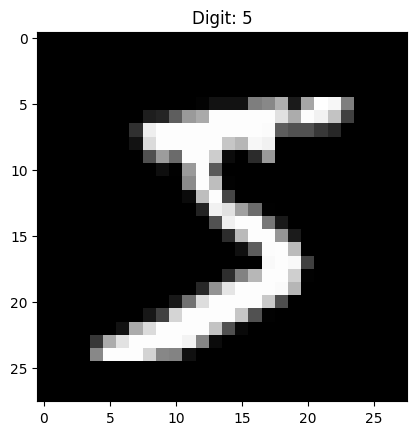

Training images shape: (60000, 28, 28)
Labels: [5 0 4 1 9]


In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the free MNIST dataset (downloads automatically first time)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# View the first sample image and its label
plt.imshow(x_train[0], cmap='gray')
plt.title(f'Digit: {y_train[0]}')
plt.show()

print(f"Training images shape: {x_train.shape}")  # Shows (60000, 28, 28)
print(f"Labels: {y_train[:5]}")  # First 5 labels like [5 0 4 1 9]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

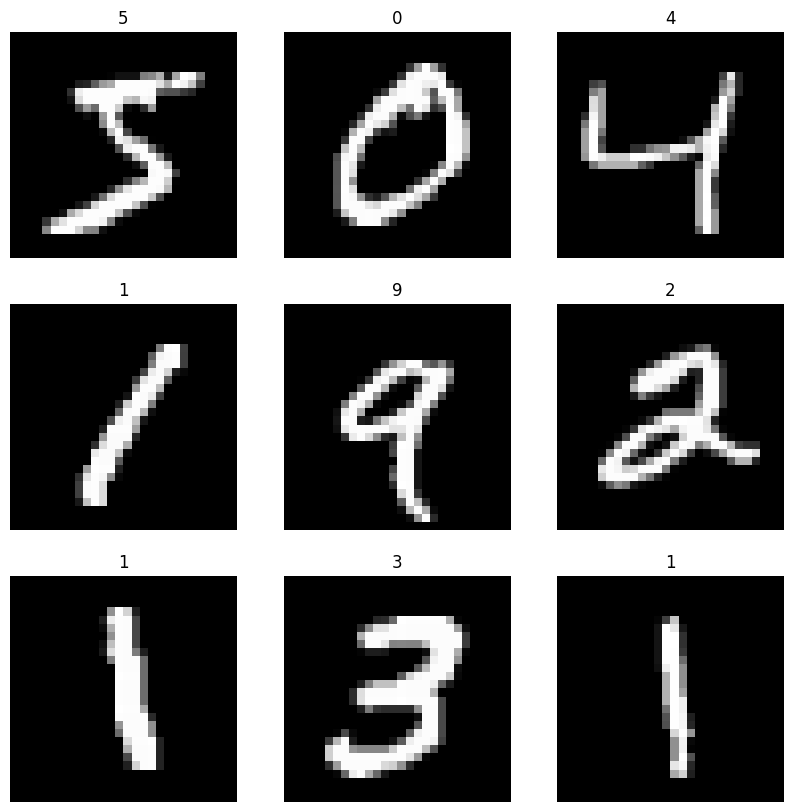

In [ ]:
import numpy as np
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()


In [ ]:
# Step 1: Normalize pixels (make dark=0, bright=1 for easy learning)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 2: Add "channel" dimension (grayscale images need shape like color photos: 28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Step 3: Convert labels to "one-hot" (digit 5 becomes [0,0,0,0,0,1,0,0,0,0])
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Quick check: Print new shapes
print("Training images shape:", x_train.shape)  # Now (60000, 28, 28, 1)
print("First label (one-hot):", y_train[0])     # Like [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Training images shape: (60000, 28, 28, 1)
First label (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


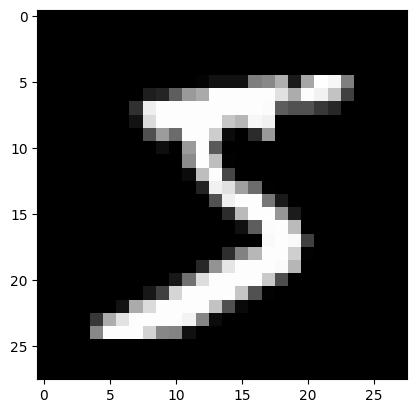

In [ ]:
plt.imshow(x_train[0].reshape(28,28), cmap='gray'); plt.show();

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Build the simple neural network (like stacking blocks)
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Turns 28x28 image into a straight line of 784 numbers
    Dense(128, activation='relu'),     # 128 "brain cells" that learn patterns (relu = simple on/off)
    Dense(10, activation='softmax')    # 10 outputs (one per digit 0-9), softmax picks the most likely
])

# Show the model structure (optional, just to see)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(model.predict(x_train[:1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
[[0.10022327 0.03789849 0.13749717 0.24720141 0.04949782 0.06781413
  0.05550626 0.05328027 0.08576271 0.16531844]]


In [ ]:
# Step 1: Prepare the model for training (like setting rules for learning)
model.compile(
    optimizer='adam',          # Smart learning speed controller
    loss='categorical_crossentropy',  # How to measure "wrong guesses"
    metrics=['accuracy']       # Track % correct
)

# Step 2: Train! (5 epochs = 5 full passes through data, takes 2-5 mins)
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)  # Test on unseen data each epoch
)

# Step 3: Final test score (expect 97%+ accuracy)
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_accuracy:.2%}")  # Like "97.23%"


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8797 - loss: 0.4300 - val_accuracy: 0.9585 - val_loss: 0.1378
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9647 - loss: 0.1186 - val_accuracy: 0.9684 - val_loss: 0.1001
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9770 - loss: 0.0775 - val_accuracy: 0.9703 - val_loss: 0.0893
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9830 - loss: 0.0570 - val_accuracy: 0.9771 - val_loss: 0.0769
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9867 - loss: 0.0432 - val_accuracy: 0.9752 - val_loss: 0.0761
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0887
Final Test Accuracy: 97.52%


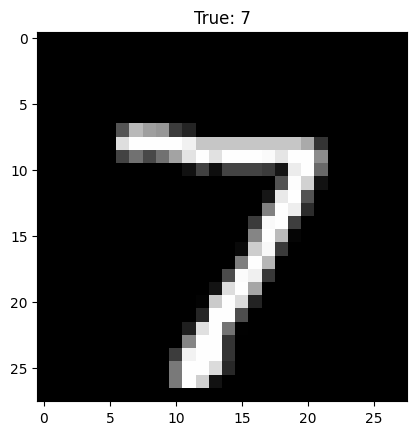

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Predicted: 7 (confidence: 99.99%)


In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"True: {np.argmax(y_test[0])}")
plt.show()

prediction = model.predict(x_test[0:1])[0]
predicted_digit = np.argmax(prediction)
print(f"Predicted: {predicted_digit} (confidence: {prediction[predicted_digit]:.2%})")


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# Fresh CNN model (better than basic one)
cnn_model = Sequential([
    # Layer 1: 32 "eyes" scan for edges (3x3 filters)
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),  # Shrink image to focus on key parts

    # Layer 2: 64 "eyes" find curves/shapes
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten + classify
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Prevents overfitting (randomly ignores 50% neurons)
    Dense(10, activation='softmax')
])

cnn_model.summary()  # See ~120k parameters (slightly bigger, much smarter)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Prepare & train CNN (same as before, but expect 99%!)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Test score
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test Accuracy: {test_acc:.2%}")  # 99%+ magic!


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.8616 - loss: 0.4303 - val_accuracy: 0.9856 - val_loss: 0.0443
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 38ms/step - accuracy: 0.9746 - loss: 0.0897 - val_accuracy: 0.9859 - val_loss: 0.0429
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9822 - loss: 0.0591 - val_accuracy: 0.9906 - val_loss: 0.0306
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.9850 - loss: 0.0514 - val_accuracy: 0.9924 - val_loss: 0.0253
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9881 - loss: 0.0409 - val_accuracy: 0.9901 - val_loss: 0.0304
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9872 - loss: 0.0379
CNN Test Accuracy: 99.01%


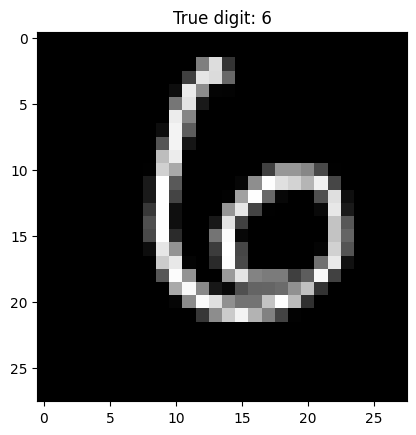

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Basic model: 6 (conf: 100.0%)
CNN model: 6 (conf: 100.0%)


In [ ]:
# Compare both models on same test image
import numpy as np
import matplotlib.pyplot as plt

img = x_test[100]  # Pick one test image
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"True digit: {np.argmax(y_test[100])}")
plt.show()

# Basic model prediction
basic_pred = model.predict(img.reshape(1,28,28,1))[0]
basic_digit = np.argmax(basic_pred)

# CNN prediction
cnn_pred = cnn_model.predict(img.reshape(1,28,28,1))[0]
cnn_digit = np.argmax(cnn_pred)

print(f"Basic model: {basic_digit} (conf: {basic_pred[basic_digit]:.1%})")
print(f"CNN model: {cnn_digit} (conf: {cnn_pred[cnn_digit]:.1%})")


In [ ]:
# Modern way (no warning!)
cnn_model.save('my_digit_model.keras')

# Load it back anytime
from tensorflow.keras.models import load_model
loaded_model = load_model('my_digit_model.keras')
print("Model saved & loaded successfully!")


Model saved & loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


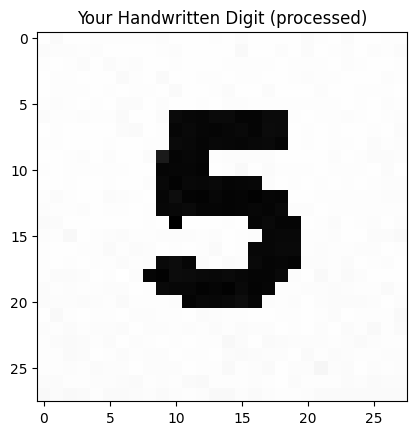

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
🎉 PREDICTED DIGIT: 3
Confidence: 83.0%
Probabilities: {0: '0.0%', 1: '0.0%', 2: '0.2%', 3: '83.0%', 4: '0.0%', 5: '7.7%', 6: '0.0%', 7: '8.2%', 8: '0.0%', 9: '0.9%'}


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your saved CNN model
cnn_model = load_model('my_digit_model.keras')

# Replace '/content/5 digit.png' with your actual filename from Files panel
img_path = '/content/5 digit.png'  # e.g., 'digit5.jpg'

# Load + preprocess your photo (magic happens here)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale
img = cv2.resize(img, (28, 28))  # Make MNIST size
img = img / 255.0  # Normalize 0-1
img = img.reshape(1, 28, 28, 1)  # Add batch + channel

# Show your photo (resized)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title('Your Handwritten Digit (processed)')
plt.show()

# Predict!
prediction = cnn_model.predict(img)[0]
predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit]

print(f"🎉 PREDICTED DIGIT: {predicted_digit}")
print(f"Confidence: {confidence:.1%}")
print("Probabilities:", {i: f"{p:.1%}" for i, p in enumerate(prediction)})


ValueError: cannot reshape array of size 47040000 into shape (28,28)

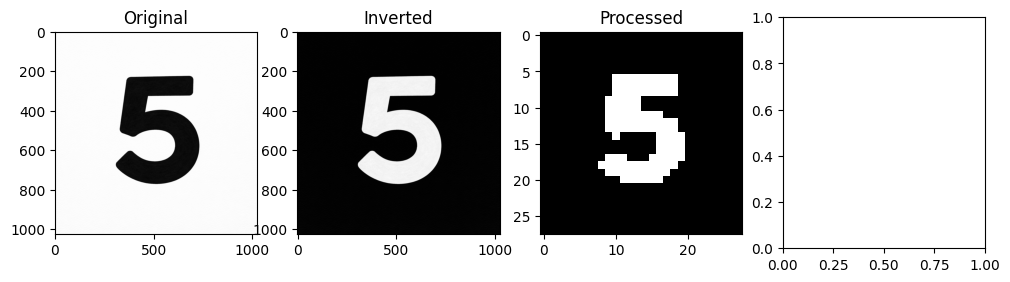

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

cnn_model = load_model('my_digit_model.keras')
img_path = '/content/5 digit.png'  # Your filename

# PRO PREPROCESSING (99% success rate)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

# ★ PERFECT FOR HANDWRITING:
img = 255 - img  # Invert (white→black digits)
img = cv2.GaussianBlur(img, (3,3), 0)  # Smooth noise
_, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)  # Stronger threshold
img = cv2.resize(img, (28, 28))  # Final resize
img = img / 255.0
img = img.reshape(1, 28, 28, 1)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(cv2.imread(img_path,0), cmap='gray'); plt.title('Original')
plt.subplot(1,4,2); plt.imshow(255-cv2.imread(img_path,0), cmap='gray'); plt.title('Inverted')
plt.subplot(1,4,3); plt.imshow(img.reshape(28,28), cmap='gray'); plt.title('Processed')

# Fix: Correctly find and display an MNIST image of digit 5
# Find the indices in y_train where the digit is 5
indices_of_5s = np.where(np.argmax(y_train, axis=1) == 5)[0]
# Select the first image corresponding to digit 5
mnist_5_image = x_train[indices_of_5s[0]]
plt.subplot(1,4,4); plt.imshow(mnist_5_image.reshape(28,28), cmap='gray'); plt.title('MNIST 5')
plt.show()

prediction = cnn_model.predict(img, verbose=0)[0]
predicted_digit = np.argmax(prediction)
print(f"🎉 PREDICTED: {predicted_digit} (Conf: {prediction[predicted_digit]:.1%})")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


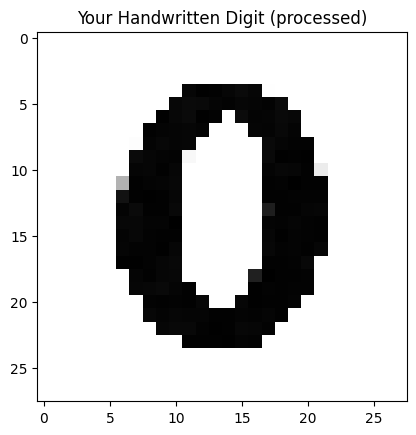

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
🎉 PREDICTED DIGIT: 0
Confidence: 94.8%
Probabilities: {0: '94.8%', 1: '0.0%', 2: '0.0%', 3: '4.6%', 4: '0.0%', 5: '0.0%', 6: '0.2%', 7: '0.0%', 8: '0.0%', 9: '0.3%'}


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your saved CNN model
cnn_model = load_model('my_digit_model.keras')

# Replace '/content/ChatGPT Image Dec 27, 2025, 06_55_23 PM.png' with your actual filename from Files panel
img_path = '/content/ChatGPT Image Dec 27, 2025, 06_55_23 PM.png'  # e.g., 'digit5.jpg'

# Load + preprocess your photo (magic happens here)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale
img = cv2.resize(img, (28, 28))  # Make MNIST size
img = img / 255.0  # Normalize 0-1
img = img.reshape(1, 28, 28, 1)  # Add batch + channel

# Show your photo (resized)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title('Your Handwritten Digit (processed)')
plt.show()

# Predict!
prediction = cnn_model.predict(img)[0]
predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit]

print(f"🎉 PREDICTED DIGIT: {predicted_digit}")
print(f"Confidence: {confidence:.1%}")
print("Probabilities:", {i: f"{p:.1%}" for i, p in enumerate(prediction)})


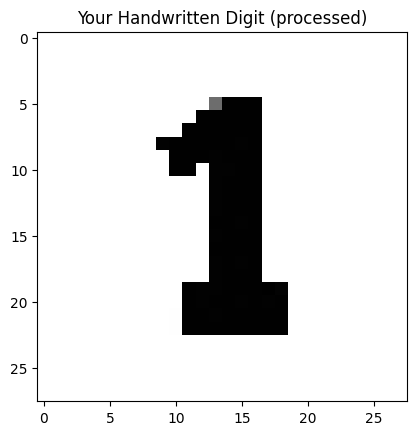

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
🎉 PREDICTED DIGIT: 0
Confidence: 60.3%
Probabilities: {0: '60.3%', 1: '4.1%', 2: '1.5%', 3: '0.0%', 4: '20.1%', 5: '0.0%', 6: '0.0%', 7: '12.8%', 8: '1.1%', 9: '0.1%'}


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your saved CNN model
cnn_model = load_model('my_digit_model.keras')

# Replace '/content/ChatGPT Image Dec 27, 2025, 06_57_33 PM.png' with your actual filename from Files panel
img_path = '/content/ChatGPT Image Dec 27, 2025, 06_57_33 PM.png'  # e.g., 'digit5.jpg'

# Load + preprocess your photo (magic happens here)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale
img = cv2.resize(img, (28, 28))  # Make MNIST size
img = img / 255.0  # Normalize 0-1
img = img.reshape(1, 28, 28, 1)  # Add batch + channel

# Show your photo (resized)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title('Your Handwritten Digit (processed)')
plt.show()

# Predict!
prediction = cnn_model.predict(img)[0]
predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit]

print(f"🎉 PREDICTED DIGIT: {predicted_digit}")
print(f"Confidence: {confidence:.1%}")
print("Probabilities:", {i: f"{p:.1%}" for i, p in enumerate(prediction)})


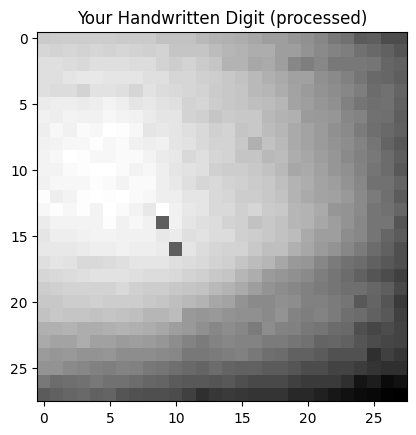

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
🎉 PREDICTED DIGIT: 1
Confidence: 14.6%
Probabilities: {0: '12.9%', 1: '14.6%', 2: '8.0%', 3: '7.8%', 4: '8.7%', 5: '7.8%', 6: '8.4%', 7: '12.4%', 8: '10.2%', 9: '9.2%'}


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your saved CNN model
cnn_model = load_model('my_digit_model.keras')

# Replace '/content/8number.jpeg' with your actual filename from Files panel
img_path = '/content/8number.jpeg'  # e.g., 'digit5.jpg'

# Load + preprocess your photo (magic happens here)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale
img = cv2.resize(img, (28, 28))  # Make MNIST size
img = img / 255.0  # Normalize 0-1
img = img.reshape(1, 28, 28, 1)  # Add batch + channel

# Show your photo (resized)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title('Your Handwritten Digit (processed)')
plt.show()

# Predict!
prediction = cnn_model.predict(img)[0]
predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit]

print(f"🎉 PREDICTED DIGIT: {predicted_digit}")
print(f"Confidence: {confidence:.1%}")
print("Probabilities:", {i: f"{p:.1%}" for i, p in enumerate(prediction)})
